# Random Forest — Predicción de producción de café · Caldas

**Partición:**
- Train: 2002-01 → 2018-12 (204 meses)
- Test: 2019-01 → 2023-12 (60 meses)
- Demo: 2024-01 → 2025-12 (reservado para el artefacto)

## Sección A — Setup, carga y visualización de la serie

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_percentage_error
from sklearn.inspection import permutation_importance
import warnings
import joblib

warnings.filterwarnings('ignore')

plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.family'] = 'DejaVu Sans'

# --- A.1 Carga e indexado temporal ---
df = pd.read_csv('cafe_seguro_master.csv', parse_dates=['fecha'])
df = df.sort_values('fecha').reset_index(drop=True)

print('=== DATASET ===')
print(f'Periodo: {df["fecha"].min().date()} → {df["fecha"].max().date()}')
print(f'Shape:   {df.shape}')
print(f'\nPrimeras filas:')
print(df.head(3).round(2))

=== DATASET ===
Periodo: 2002-01-01 → 2025-12-01
Shape:   (288, 10)

Primeras filas:
       fecha  year  month  prod_caldas_miles_sacos  prod_nacional_miles_sacos  \
0 2002-01-01  2002      1                    84.60                      824.0   
1 2002-02-01  2002      2                    82.96                      808.0   
2 2002-03-01  2002      3                    79.88                      778.0   

   precip_mm  ndvi_mean  ndvi_median  ndvi_p90  precio_interno_cop  
0     118.09       0.80         0.82      0.89            276480.0  
1     135.23       0.75         0.78      0.87            270960.0  
2     234.07       0.68         0.73      0.85            296859.0  


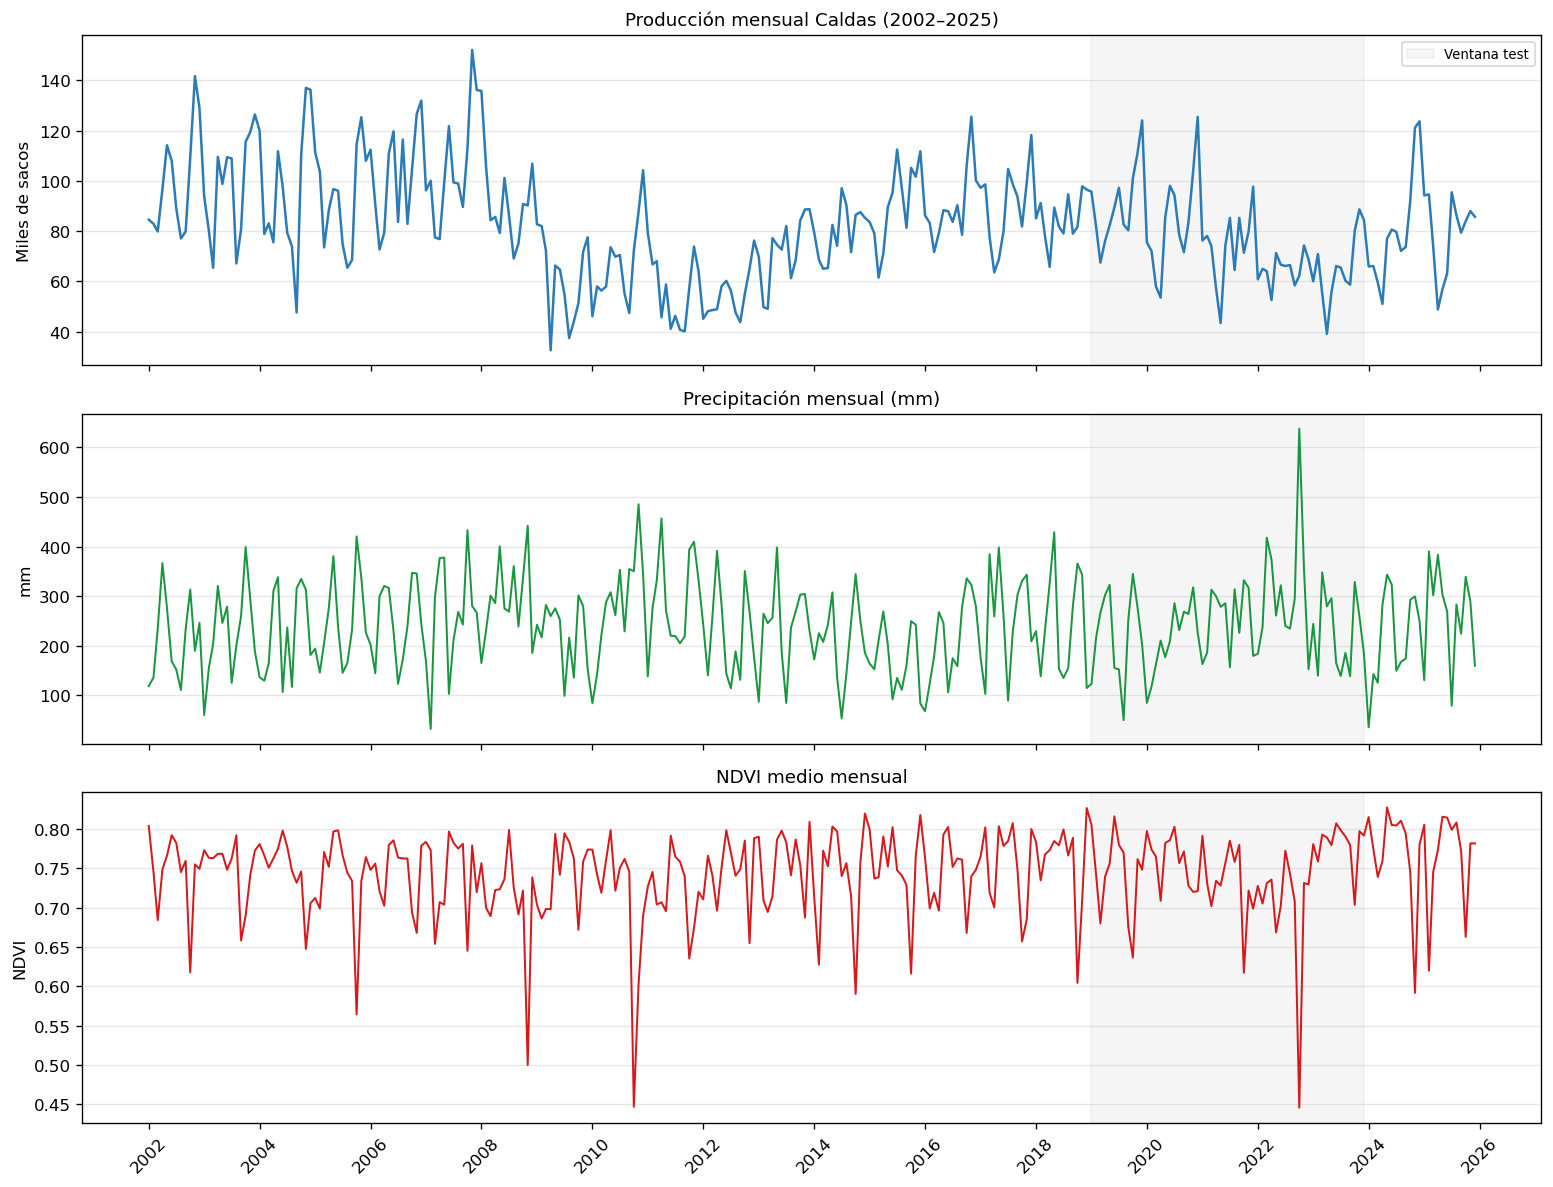

Gráfica guardada: rfA_serie_temporal.png


In [6]:
# --- A.2 Visualización de la serie objetivo y covariables ---
fig, axes = plt.subplots(3, 1, figsize=(13, 10), sharex=True)

axes[0].plot(df['fecha'], df['prod_caldas_miles_sacos'], color='#2c7bb6', lw=1.5)
axes[0].axvspan(pd.Timestamp('2019-01-01'), pd.Timestamp('2023-12-01'),
                alpha=0.08, color='gray', label='Ventana test')
axes[0].set_ylabel('Miles de sacos')
axes[0].set_title('Producción mensual Caldas (2002–2025)', fontsize=11)
axes[0].legend(fontsize=8)
axes[0].grid(axis='y', alpha=0.3)

axes[1].plot(df['fecha'], df['precip_mm'], color='#1a9641', lw=1.2)
axes[1].axvspan(pd.Timestamp('2019-01-01'), pd.Timestamp('2023-12-01'),
                alpha=0.08, color='gray')
axes[1].set_ylabel('mm')
axes[1].set_title('Precipitación mensual (mm)', fontsize=11)
axes[1].grid(axis='y', alpha=0.3)

axes[2].plot(df['fecha'], df['ndvi_mean'], color='#d7191c', lw=1.2)
axes[2].axvspan(pd.Timestamp('2019-01-01'), pd.Timestamp('2023-12-01'),
                alpha=0.08, color='gray')
axes[2].set_ylabel('NDVI')
axes[2].set_title('NDVI medio mensual', fontsize=11)
axes[2].xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
axes[2].xaxis.set_major_locator(mdates.YearLocator(2))
axes[2].grid(axis='y', alpha=0.3)

plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('rfA_serie_temporal.png', dpi=150, bbox_inches='tight')
plt.show()
print('Gráfica guardada: rfA_serie_temporal.png')

## Sección B — Feature Engineering

A diferencia de SARIMAX, Random Forest no captura estructura temporal automáticamente.
Hay que construir explícitamente las variables que representen:
- Rezagos de producción (valores pasados como predictores)
- Rezagos de precipitación y NDVI (lag óptimos identificados en el ETL)
- Estacionalidad (mes del año como variable cíclica)
- Tendencia (índice temporal)

In [8]:
TARGET = 'prod_caldas_miles_sacos'

# --- B.1 Construcción de features ---
df_feat = df.copy()

# Rezagos de producción: capturan dependencia temporal (AR manual)
for lag in [1, 2, 3, 6, 12]:
    df_feat[f'prod_lag{lag}'] = df_feat[TARGET].shift(lag)

# Rezagos de precipitación: lag óptimo identificado en ETL = 10 meses
for lag in [1, 3, 6, 10]:
    df_feat[f'precip_lag{lag}'] = df_feat['precip_mm'].shift(lag)

# Rezagos de NDVI: lag óptimo identificado en ETL = 5 meses
for lag in [1, 3, 5]:
    df_feat[f'ndvi_lag{lag}'] = df_feat['ndvi_mean'].shift(lag)

# Estacionalidad cíclica: seno y coseno del mes para capturar periodicidad
df_feat['mes_sin'] = np.sin(2 * np.pi * df_feat['month'] / 12)
df_feat['mes_cos'] = np.cos(2 * np.pi * df_feat['month'] / 12)

# Tendencia lineal
df_feat['tendencia'] = np.arange(len(df_feat))

# Eliminar filas con NaN generados por los rezagos
df_feat = df_feat.dropna().reset_index(drop=True)

print('=== FEATURES CONSTRUIDAS ===')
FEATURE_COLS = [
    'prod_lag1', 'prod_lag2', 'prod_lag3', 'prod_lag6', 'prod_lag12',
    'precip_lag1', 'precip_lag3', 'precip_lag6', 'precip_lag10',
    'ndvi_lag1', 'ndvi_lag3', 'ndvi_lag5',
    'mes_sin', 'mes_cos', 'tendencia'
]
print(f'Total features: {len(FEATURE_COLS)}')
for f in FEATURE_COLS:
    print(f'  {f}')
print(f'\nRegistros tras eliminar NaN por rezagos: {len(df_feat)}')
print(f'Periodo efectivo: {df_feat["fecha"].min().date()} → {df_feat["fecha"].max().date()}')

=== FEATURES CONSTRUIDAS ===
Total features: 15
  prod_lag1
  prod_lag2
  prod_lag3
  prod_lag6
  prod_lag12
  precip_lag1
  precip_lag3
  precip_lag6
  precip_lag10
  ndvi_lag1
  ndvi_lag3
  ndvi_lag5
  mes_sin
  mes_cos
  tendencia

Registros tras eliminar NaN por rezagos: 276
Periodo efectivo: 2003-01-01 → 2025-12-01


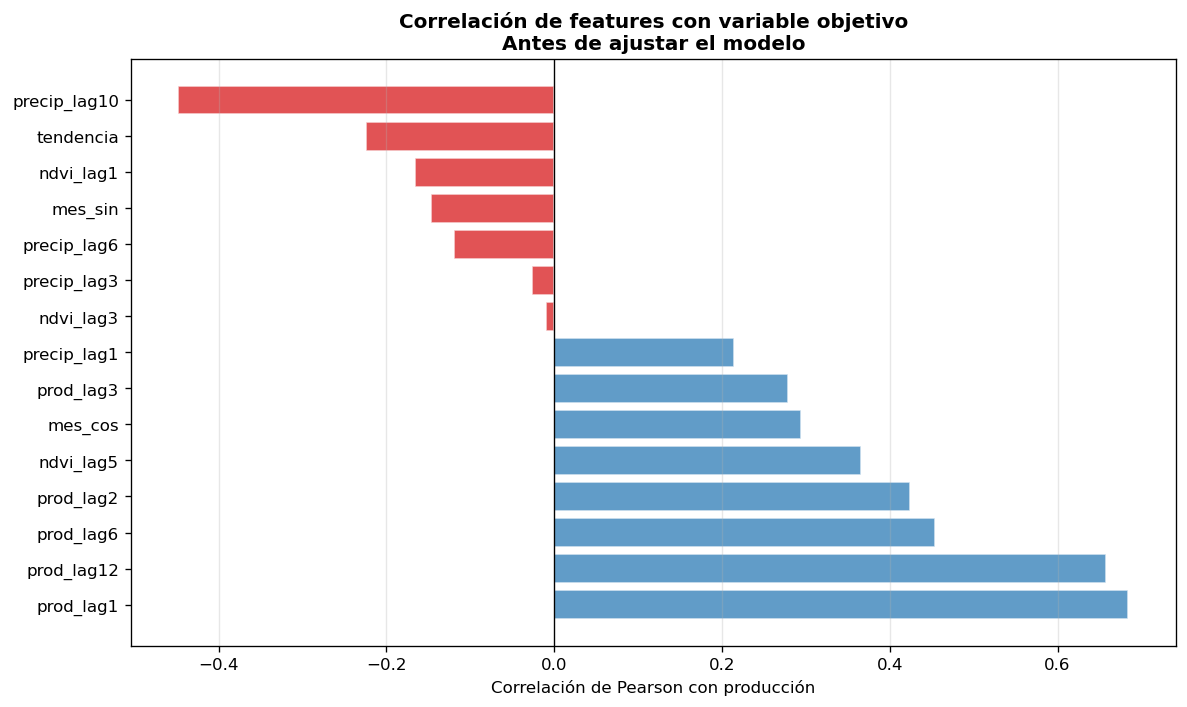

Gráfica guardada: rfB_correlacion_features.png

=== CORRELACIÓN FEATURES vs TARGET ===
prod_lag1       0.685
prod_lag12      0.658
prod_lag6       0.454
prod_lag2       0.424
ndvi_lag5       0.365
mes_cos         0.294
prod_lag3       0.279
precip_lag1     0.214
ndvi_lag3      -0.010
precip_lag3    -0.027
precip_lag6    -0.120
mes_sin        -0.146
ndvi_lag1      -0.166
tendencia      -0.225
precip_lag10   -0.448


In [9]:
# --- B.2 Matriz de correlación features vs target ---
corr_cols = FEATURE_COLS + [TARGET]
corr = df_feat[corr_cols].corr()[TARGET].drop(TARGET).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(10, 6))
colores_corr = ['#2c7bb6' if v > 0 else '#d7191c' for v in corr.values]
ax.barh(corr.index, corr.values, color=colores_corr, alpha=0.75, edgecolor='white')
ax.axvline(0, color='black', lw=0.8)
ax.set_xlabel('Correlación de Pearson con producción')
ax.set_title('Correlación de features con variable objetivo\nAntes de ajustar el modelo', fontweight='bold')
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.savefig('rfB_correlacion_features.png', dpi=150, bbox_inches='tight')
plt.show()
print('Gráfica guardada: rfB_correlacion_features.png')

print('\n=== CORRELACIÓN FEATURES vs TARGET ===')
print(corr.round(3).to_string())

## Sección C — Partición train / test / demo

In [13]:
# --- C.1 Partición temporal estricta ---
# Random Forest no tiene memoria temporal implícita, por eso es crítico
# que la partición sea estrictamente por fecha (nunca aleatoria en series de tiempo)

train_df = df_feat[df_feat['fecha'] <= '2018-12-01'].copy()
test_df  = df_feat[(df_feat['fecha'] >= '2019-01-01') & (df_feat['fecha'] <= '2023-12-01')].copy()
demo_df  = df_feat[df_feat['fecha'] >= '2024-01-01'].copy()

X_train = train_df[FEATURE_COLS]
y_train = train_df[TARGET]
X_test  = test_df[FEATURE_COLS]
y_test  = test_df[TARGET]
X_demo  = demo_df[FEATURE_COLS]
y_demo  = demo_df[TARGET]

print('=== PARTICIÓN WALK-FORWARD ===')
print(f'Train: {train_df["fecha"].min().date()} → {train_df["fecha"].max().date()} | {len(train_df)} meses')
print(f'Test:  {test_df["fecha"].min().date()}  → {test_df["fecha"].max().date()}  | {len(test_df)} meses')
print(f'Demo:  {demo_df["fecha"].min().date()}  → {demo_df["fecha"].max().date()}  | {len(demo_df)} meses')
print(f'Total: {len(train_df)+len(test_df)+len(demo_df)} meses')

=== PARTICIÓN WALK-FORWARD ===
Train: 2003-01-01 → 2018-12-01 | 192 meses
Test:  2019-01-01  → 2023-12-01  | 60 meses
Demo:  2024-01-01  → 2025-12-01  | 24 meses
Total: 276 meses


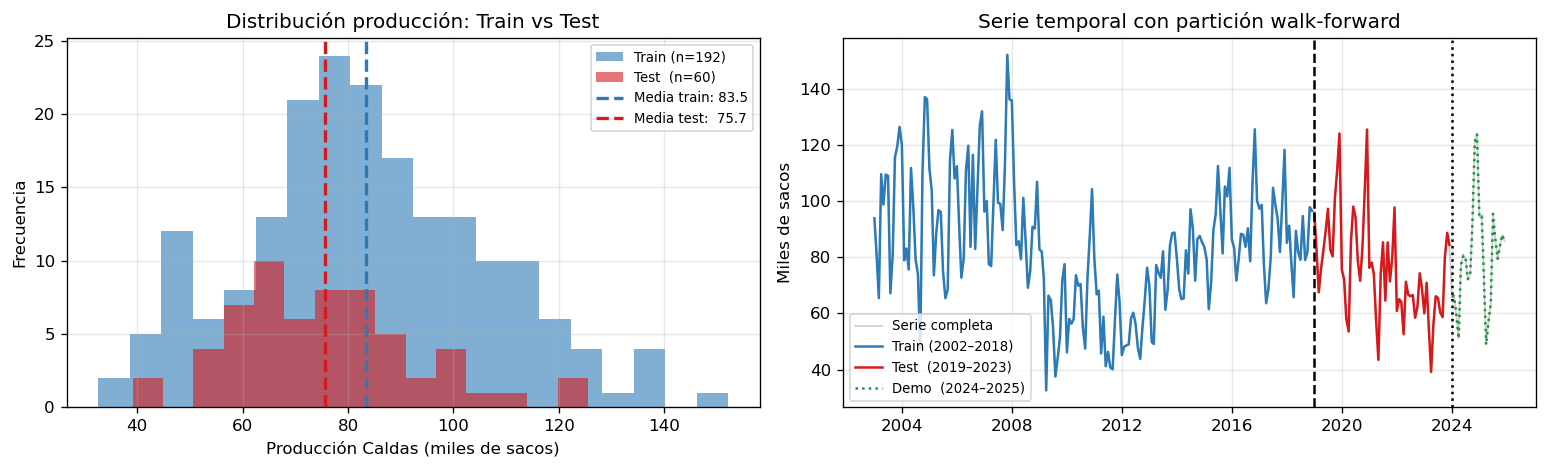

Gráfica guardada: rfC_particion_train_test.png

=== ESTADÍSTICA COMPARATIVA TRAIN vs TEST ===
       Train (2002–2018)  Test  (2019–2023)
count             192.00              60.00
mean               83.47              75.65
std                22.90              17.50
min                32.60              39.14
25%                68.63              64.44
50%                81.94              74.16
75%                98.67              84.62
max               152.11             125.50


In [16]:
# --- C.2 Verificación distribución train vs test ---
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].hist(y_train, bins=20, alpha=0.6, color='#2c7bb6', label=f'Train (n={len(y_train)})')
axes[0].hist(y_test,  bins=15, alpha=0.6, color='#d7191c', label=f'Test  (n={len(y_test)})')
axes[0].axvline(y_train.mean(), color='#2c7bb6', lw=2, linestyle='--',
                label=f'Media train: {y_train.mean():.1f}')
axes[0].axvline(y_test.mean(),  color='#d7191c', lw=2, linestyle='--',
                label=f'Media test:  {y_test.mean():.1f}')
axes[0].set_xlabel('Producción Caldas (miles de sacos)')
axes[0].set_ylabel('Frecuencia')
axes[0].set_title('Distribución producción: Train vs Test')
axes[0].legend(fontsize=8)
axes[0].grid(alpha=0.3)

axes[1].plot(df_feat['fecha'], df_feat[TARGET], color='gray', lw=1, alpha=0.4, label='Serie completa')
axes[1].plot(train_df['fecha'], y_train, color='#2c7bb6', lw=1.5, label='Train (2002–2018)')
axes[1].plot(test_df['fecha'],  y_test,  color='#d7191c', lw=1.5, label='Test  (2019–2023)')
axes[1].plot(demo_df['fecha'],  y_demo,  color='#1a9641', lw=1.5, linestyle=':', label='Demo  (2024–2025)')
axes[1].axvline(pd.Timestamp('2019-01-01'), color='black', lw=1.5, linestyle='--')
axes[1].axvline(pd.Timestamp('2024-01-01'), color='black', lw=1.5, linestyle=':')
axes[1].set_ylabel('Miles de sacos')
axes[1].set_title('Serie temporal con partición walk-forward')
axes[1].legend(fontsize=8)
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('rfC_particion_train_test.png', dpi=150, bbox_inches='tight')
plt.show()
print('Gráfica guardada: rfC_particion_train_test.png')

print('\n=== ESTADÍSTICA COMPARATIVA TRAIN vs TEST ===')
comp = pd.DataFrame({
    'Train (2002–2018)': y_train.describe(),
    'Test  (2019–2023)': y_test.describe()
}).round(2)
print(comp.to_string())

## Sección D — Entrenamiento de modelos Random Forest

Se evalúan cuatro especificaciones de complejidad creciente:
- **M1**: parámetros por defecto (línea base)
- **M2**: mayor número de árboles, sin restricción de profundidad
- **M3**: restricción de profundidad máxima para reducir sobreajuste
- **M4**: configuración optimizada con min_samples_leaf para series de tiempo

In [18]:
# --- D.1 Función auxiliar de métricas ---
def calcular_metricas(y_real, y_pred, nombre, split):
    rmse = np.sqrt(mean_squared_error(y_real, y_pred))
    mape = mean_absolute_percentage_error(y_real, y_pred) * 100
    ss_res = np.sum((np.array(y_real) - np.array(y_pred)) ** 2)
    ss_tot = np.sum((np.array(y_real) - np.array(y_real).mean()) ** 2)
    r2 = 1 - ss_res / ss_tot
    return {
        'modelo': nombre, 'split': split,
        'RMSE': round(rmse, 3),
        'MAPE': round(mape, 3),
        'R2':   round(r2, 3)
    }

print('Función de métricas definida.')

Función de métricas definida.


In [21]:
# --- D.2 Definición de especificaciones ---
ESPECIFICACIONES = {
    'M1_rf_base': {
        'n_estimators': 100,
        'max_depth': None,
        'min_samples_leaf': 1,
        'min_samples_split': 2,
        'max_features': 'sqrt',
        'random_state': 42
    },
    'M2_rf_mas_arboles': {
        'n_estimators': 500,
        'max_depth': None,
        'min_samples_leaf': 1,
        'min_samples_split': 2,
        'max_features': 'sqrt',
        'random_state': 42
    },
    'M3_rf_profundidad': {
        'n_estimators': 500,
        'max_depth': 8,
        'min_samples_leaf': 2,
        'min_samples_split': 5,
        'max_features': 'sqrt',
        'random_state': 42
    },
    'M4_rf_optimizado': {
        'n_estimators': 500,
        'max_depth': 10,
        'min_samples_leaf': 4,
        'min_samples_split': 8,
        'max_features': 0.7,
        'random_state': 42
    },
}

print('=== ESPECIFICACIONES RANDOM FOREST ===')
for nombre, params in ESPECIFICACIONES.items():
    print(f"\n{nombre}:")
    for k, v in params.items():
        if k != 'random_state':
            print(f'  {k}: {v}')

=== ESPECIFICACIONES RANDOM FOREST ===

M1_rf_base:
  n_estimators: 100
  max_depth: None
  min_samples_leaf: 1
  min_samples_split: 2
  max_features: sqrt

M2_rf_mas_arboles:
  n_estimators: 500
  max_depth: None
  min_samples_leaf: 1
  min_samples_split: 2
  max_features: sqrt

M3_rf_profundidad:
  n_estimators: 500
  max_depth: 8
  min_samples_leaf: 2
  min_samples_split: 5
  max_features: sqrt

M4_rf_optimizado:
  n_estimators: 500
  max_depth: 10
  min_samples_leaf: 4
  min_samples_split: 8
  max_features: 0.7


In [23]:
# --- D.3 Entrenamiento y predicción ---
resultados = {}
metricas_todas = []

for nombre, params in ESPECIFICACIONES.items():
    print(f"\n{'='*60}")
    print(f"MODELO: {nombre}")
    print(f"{'='*60}")

    modelo = RandomForestRegressor(**params)
    modelo.fit(X_train, y_train)

    pred_train = modelo.predict(X_train)
    pred_test  = modelo.predict(X_test)

    met_train = calcular_metricas(y_train, pred_train, nombre, 'train')
    met_test  = calcular_metricas(y_test,  pred_test,  nombre, 'test')

    metricas_todas.append(met_train)
    metricas_todas.append(met_test)

    resultados[nombre] = {
        'modelo':     modelo,
        'pred_train': pred_train,
        'pred_test':  pred_test,
        'params':     params
    }

    print(f'  RMSE train: {met_train["RMSE"]:.3f} | RMSE test: {met_test["RMSE"]:.3f}')
    print(f'  MAPE train: {met_train["MAPE"]:.2f}% | MAPE test: {met_test["MAPE"]:.2f}%')
    print(f'  R²   train: {met_train["R2"]:.3f}  | R²   test: {met_test["R2"]:.3f}')


MODELO: M1_rf_base
  RMSE train: 4.509 | RMSE test: 10.665
  MAPE train: 4.67% | MAPE test: 12.13%
  R²   train: 0.961  | R²   test: 0.622

MODELO: M2_rf_mas_arboles
  RMSE train: 4.416 | RMSE test: 10.738
  MAPE train: 4.45% | MAPE test: 12.49%
  R²   train: 0.963  | R²   test: 0.617

MODELO: M3_rf_profundidad
  RMSE train: 6.487 | RMSE test: 10.731
  MAPE train: 6.48% | MAPE test: 12.41%
  R²   train: 0.919  | R²   test: 0.618

MODELO: M4_rf_optimizado
  RMSE train: 7.339 | RMSE test: 10.556
  MAPE train: 7.30% | MAPE test: 11.71%
  R²   train: 0.897  | R²   test: 0.630


In [24]:
# --- D.4 Tabla comparativa de métricas ---
df_metricas = pd.DataFrame(metricas_todas)
tabla = df_metricas.pivot(index='modelo', columns='split', values=['RMSE','MAPE','R2'])
tabla.columns = ['_'.join(col).strip() for col in tabla.columns]
tabla = tabla[['RMSE_train','RMSE_test','MAPE_train','MAPE_test','R2_train','R2_test']]

print('\n' + '='*75)
print('TABLA COMPARATIVA — 4 MODELOS RANDOM FOREST')
print('='*75)
print(tabla.to_string())

# Mejor modelo en test por RMSE
mejor = tabla['RMSE_test'].idxmin()
print(f'\n→ Mejor modelo en test (RMSE): {mejor}')
print(f'  RMSE test : {tabla.loc[mejor,"RMSE_test"]}')
print(f'  MAPE test : {tabla.loc[mejor,"MAPE_test"]}%')
print(f'  R²   test : {tabla.loc[mejor,"R2_test"]}')

# Alerta de sobreajuste
print('\n=== ANÁLISIS DE SOBREAJUSTE ===')
for modelo in tabla.index:
    gap = tabla.loc[modelo,'RMSE_test'] - tabla.loc[modelo,'RMSE_train']
    ratio = tabla.loc[modelo,'RMSE_test'] / tabla.loc[modelo,'RMSE_train']
    flag = '⚠ SOBREAJUSTE' if ratio > 1.5 else '✓ OK'
    print(f'  {modelo}: gap RMSE={gap:.3f} | ratio={ratio:.2f} {flag}')


TABLA COMPARATIVA — 4 MODELOS RANDOM FOREST
                   RMSE_train  RMSE_test  MAPE_train  MAPE_test  R2_train  R2_test
modelo                                                                            
M1_rf_base              4.509     10.665       4.666     12.126     0.961    0.622
M2_rf_mas_arboles       4.416     10.738       4.449     12.487     0.963    0.617
M3_rf_profundidad       6.487     10.731       6.484     12.407     0.919    0.618
M4_rf_optimizado        7.339     10.556       7.305     11.714     0.897    0.630

→ Mejor modelo en test (RMSE): M4_rf_optimizado
  RMSE test : 10.556
  MAPE test : 11.714%
  R²   test : 0.63

=== ANÁLISIS DE SOBREAJUSTE ===
  M1_rf_base: gap RMSE=6.156 | ratio=2.37 ⚠ SOBREAJUSTE
  M2_rf_mas_arboles: gap RMSE=6.322 | ratio=2.43 ⚠ SOBREAJUSTE
  M3_rf_profundidad: gap RMSE=4.244 | ratio=1.65 ⚠ SOBREAJUSTE
  M4_rf_optimizado: gap RMSE=3.217 | ratio=1.44 ✓ OK


## Sección E — Visualización de predicciones

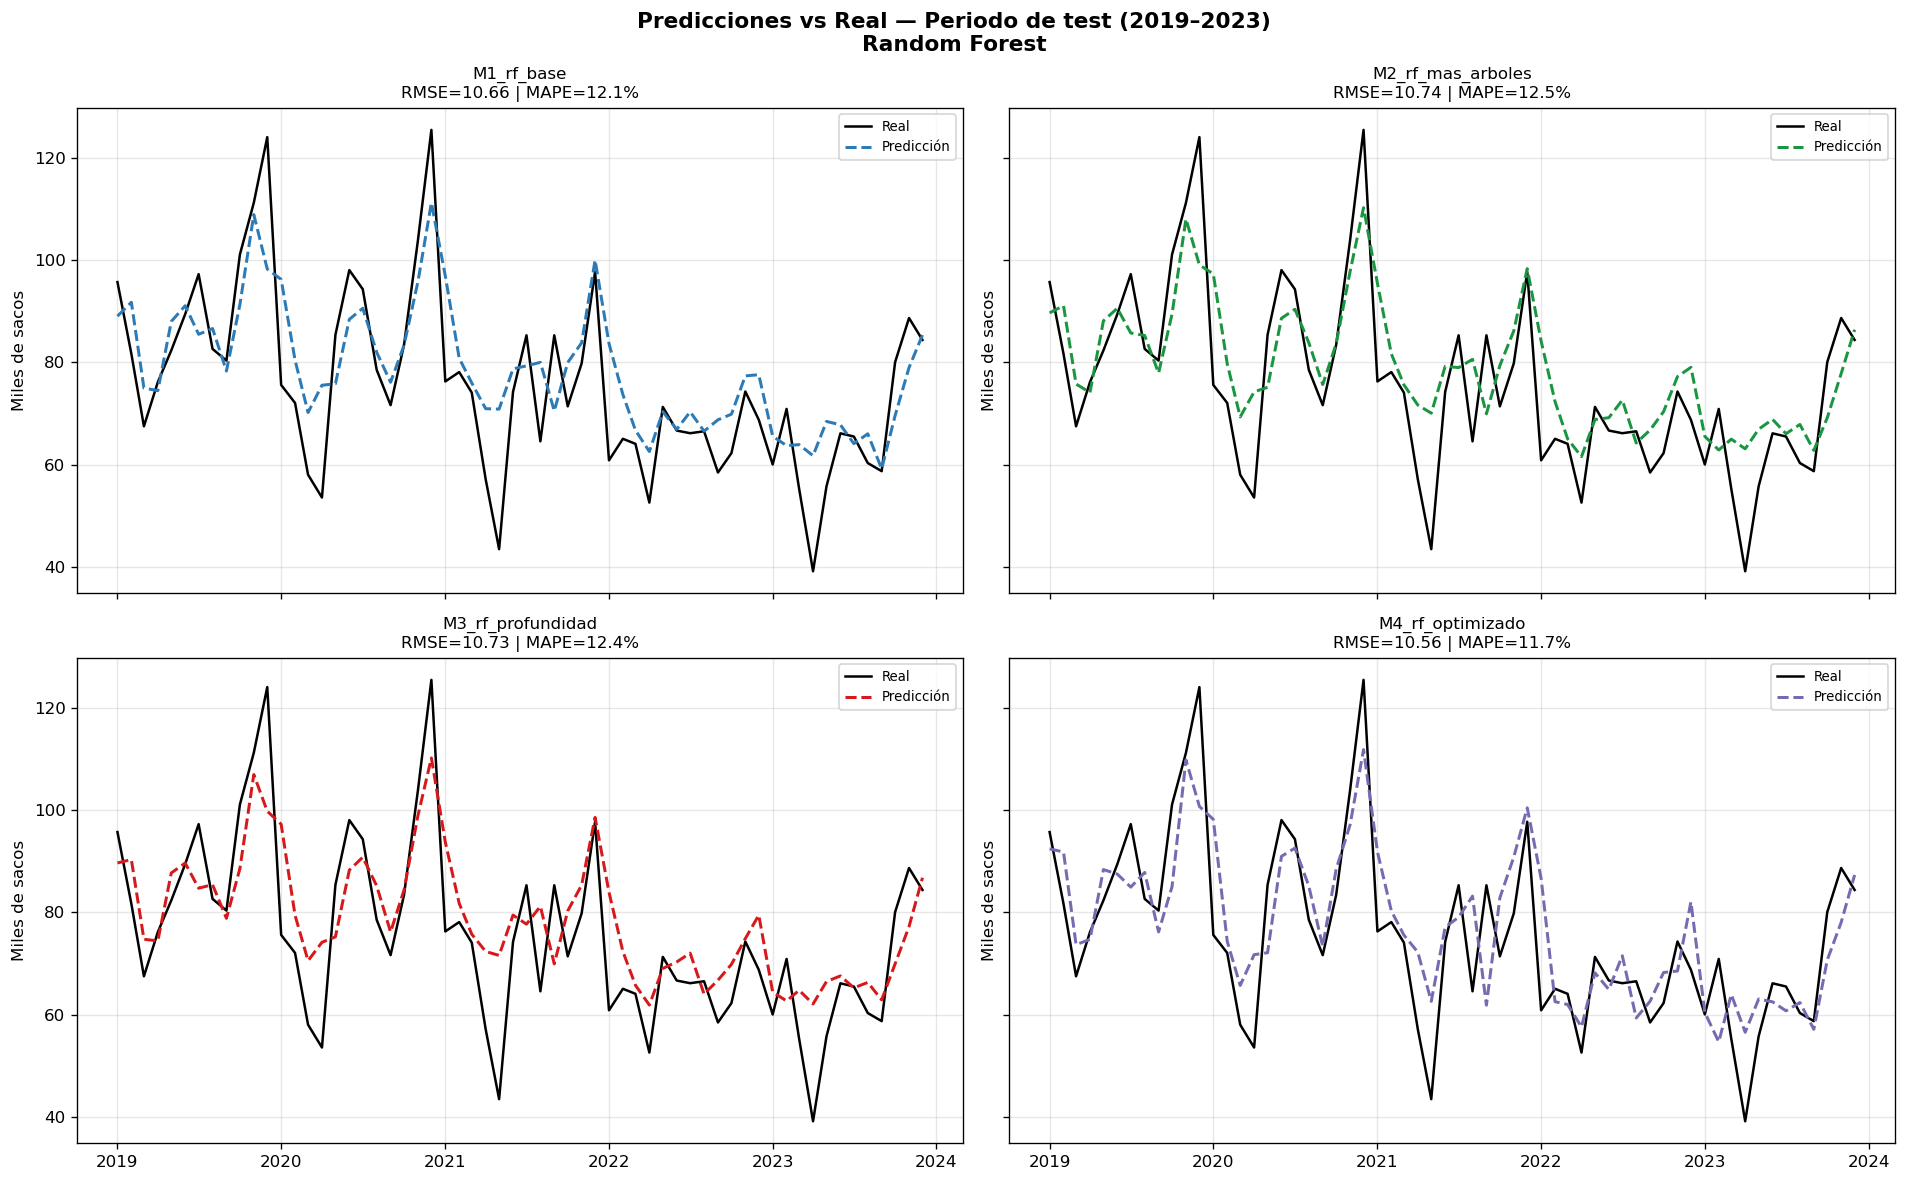

Gráfica guardada: rfE_predicciones_test.png


In [28]:
# --- E.1 Predicciones vs valores reales en periodo de test (4 modelos) ---
fig, axes = plt.subplots(2, 2, figsize=(16, 10), sharex=True, sharey=True)
axes = axes.flatten()
colores = ['#2c7bb6', '#1a9641', '#d7191c', '#756bb1']

for i, (nombre, res) in enumerate(resultados.items()):
    ax = axes[i]
    rmse_te = np.sqrt(mean_squared_error(y_test, res['pred_test']))
    mape_te = mean_absolute_percentage_error(y_test, res['pred_test']) * 100

    ax.plot(test_df['fecha'], y_test.values,       color='black',    lw=1.5, label='Real',       zorder=3)
    ax.plot(test_df['fecha'], res['pred_test'],     color=colores[i], lw=1.8, linestyle='--',
            label='Predicción', zorder=3)

    ax.set_title(f'{nombre}\nRMSE={rmse_te:.2f} | MAPE={mape_te:.1f}%', fontsize=10)
    ax.set_ylabel('Miles de sacos')
    ax.legend(fontsize=8)
    ax.grid(alpha=0.3)
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

plt.suptitle('Predicciones vs Real — Periodo de test (2019–2023)\nRandom Forest', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('rfE_predicciones_test.png', dpi=150, bbox_inches='tight')
plt.show()
print('Gráfica guardada: rfE_predicciones_test.png')

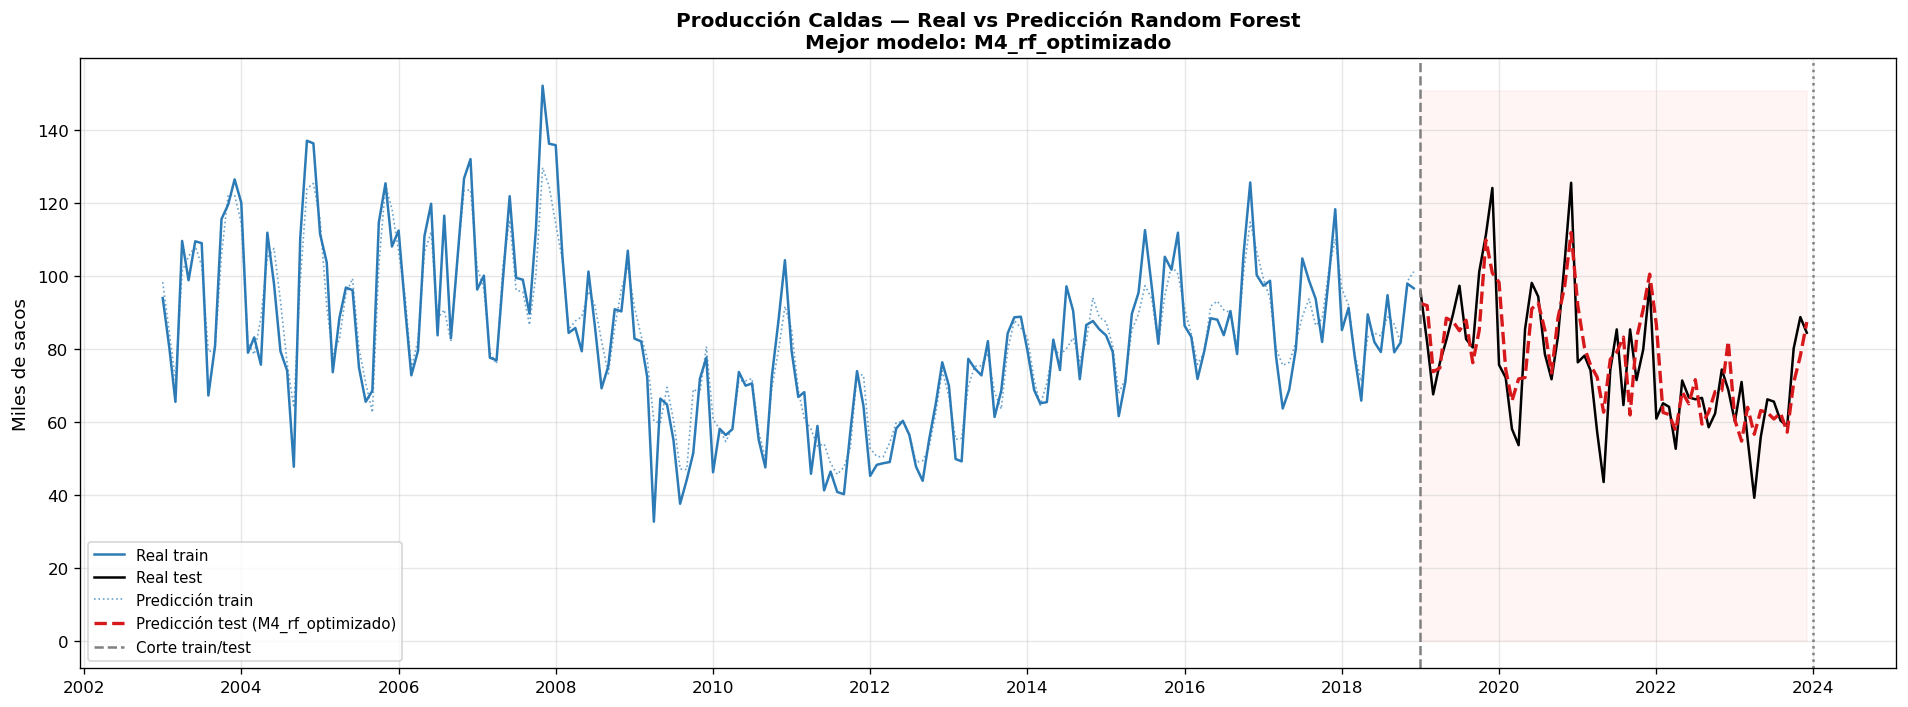

Gráfica guardada: rfE_serie_completa_mejor_modelo.png


In [29]:
# --- E.2 Serie completa: train + test + predicción del mejor modelo ---
mejor_res = resultados[mejor]

fig, ax = plt.subplots(figsize=(16, 6))

ax.plot(train_df['fecha'], y_train.values,              color='#2c7bb6', lw=1.5,  label='Real train')
ax.plot(test_df['fecha'],  y_test.values,               color='black',   lw=1.5,  label='Real test')
ax.plot(train_df['fecha'], mejor_res['pred_train'],     color='#2c7bb6', lw=1,    linestyle=':', alpha=0.7,
        label='Predicción train')
ax.plot(test_df['fecha'],  mejor_res['pred_test'],      color='#d7191c', lw=2,    linestyle='--',
        label=f'Predicción test ({mejor})')

ax.axvline(pd.Timestamp('2019-01-01'), color='gray', lw=1.5, linestyle='--', label='Corte train/test')
ax.axvline(pd.Timestamp('2024-01-01'), color='gray', lw=1.5, linestyle=':')
ax.fill_between(test_df['fecha'], 0, y_test.max() * 1.2, alpha=0.04, color='red')

ax.set_ylabel('Miles de sacos', fontsize=11)
ax.set_title(f'Producción Caldas — Real vs Predicción Random Forest\nMejor modelo: {mejor}',
             fontsize=12, fontweight='bold')
ax.legend(fontsize=9)
ax.grid(alpha=0.3)
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
ax.xaxis.set_major_locator(mdates.YearLocator(2))

plt.tight_layout()
plt.savefig('rfE_serie_completa_mejor_modelo.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Gráfica guardada: rfE_serie_completa_mejor_modelo.png')

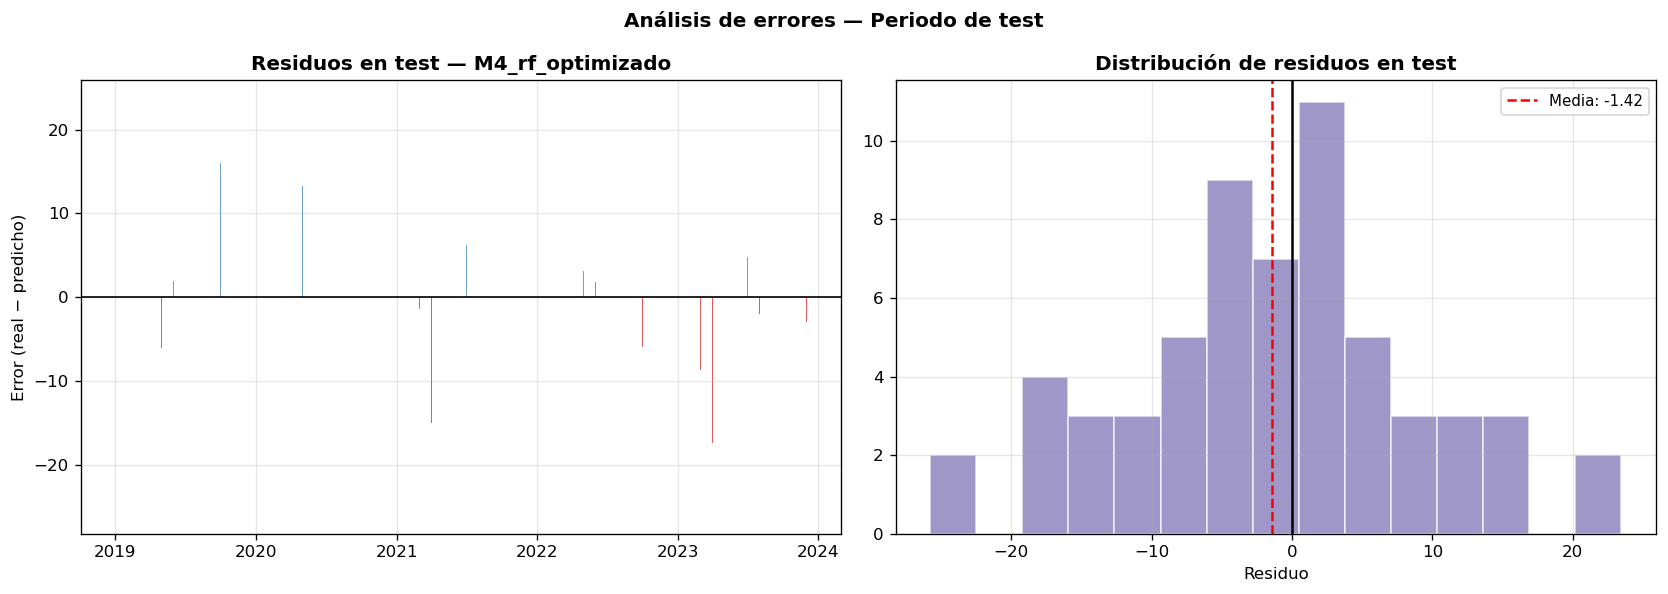

Gráfica guardada: rfE_residuos_test.png


In [31]:
# --- E.3 Análisis de residuos del mejor modelo ---
residuos = y_test.values - mejor_res['pred_test']

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].bar(test_df['fecha'], residuos,
            color=['#d7191c' if r < 0 else '#2c7bb6' for r in residuos], alpha=0.7)
axes[0].axhline(0, color='black', lw=1)
axes[0].set_ylabel('Error (real − predicho)')
axes[0].set_title(f'Residuos en test — {mejor}', fontweight='bold')
axes[0].grid(alpha=0.3)
axes[0].xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

axes[1].hist(residuos, bins=15, color='#756bb1', alpha=0.7, edgecolor='white')
axes[1].axvline(0,                  color='black', lw=1.5)
axes[1].axvline(np.mean(residuos),  color='red',   lw=1.5, linestyle='--',
                label=f'Media: {np.mean(residuos):.2f}')
axes[1].set_xlabel('Residuo')
axes[1].set_title('Distribución de residuos en test', fontweight='bold')
axes[1].legend(fontsize=9)
axes[1].grid(alpha=0.3)

plt.suptitle('Análisis de errores — Periodo de test', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('rfE_residuos_test.png', dpi=150, bbox_inches='tight')
plt.show()
print('Gráfica guardada: rfE_residuos_test.png')

## Sección F — Importancia de variables e interpretabilidad

A diferencia de los modelos lineales, Random Forest permite calcular la importancia
de cada feature. Esto es clave para el proyecto porque permite identificar cuáles
variables climáticas y de producción pasada son más relevantes para predecir la producción,
lo que respalda el diseño del índice de activación del seguro.

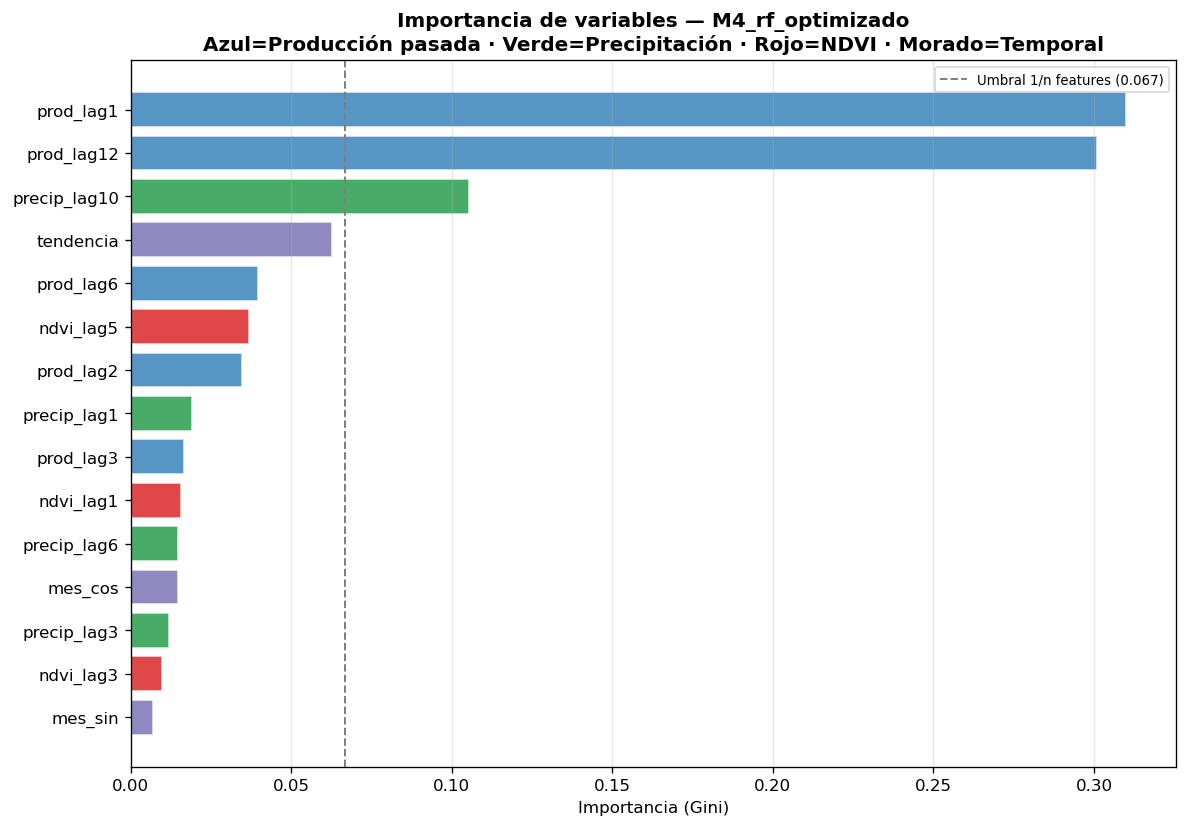

Gráfica guardada: rfF_importancia_variables.png

=== RANKING DE IMPORTANCIA ===
  prod_lag1           : 0.3101  ███████████████████████████████
  prod_lag12          : 0.3011  ██████████████████████████████
  precip_lag10        : 0.1052  ██████████
  tendencia           : 0.0626  ██████
  prod_lag6           : 0.0398  ███
  ndvi_lag5           : 0.0369  ███
  prod_lag2           : 0.0348  ███
  precip_lag1         : 0.0191  █
  prod_lag3           : 0.0166  █
  ndvi_lag1           : 0.0156  █
  precip_lag6         : 0.0148  █
  mes_cos             : 0.0147  █
  precip_lag3         : 0.0119  █
  ndvi_lag3           : 0.0097  
  mes_sin             : 0.0071  


In [34]:
# --- F.1 Importancia de variables (feature importance del mejor modelo) ---
mejor_modelo_obj = mejor_res['modelo']
importancias = pd.Series(
    mejor_modelo_obj.feature_importances_,
    index=FEATURE_COLS
).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(10, 7))
colores_imp = ['#2c7bb6' if 'prod' in f
               else '#1a9641' if 'precip' in f
               else '#d7191c' if 'ndvi' in f
               else '#756bb1'
               for f in importancias.index]

ax.barh(importancias.index[::-1], importancias.values[::-1],
        color=colores_imp[::-1], alpha=0.8, edgecolor='white')
ax.set_xlabel('Importancia (Gini)')
ax.set_title(f'Importancia de variables — {mejor}\n'
             f'Azul=Producción pasada · Verde=Precipitación · Rojo=NDVI · Morado=Temporal',
             fontweight='bold')
ax.grid(axis='x', alpha=0.3)

# Línea de importancia umbral (1/n features)
umbral = 1 / len(FEATURE_COLS)
ax.axvline(umbral, color='gray', lw=1.2, linestyle='--',
           label=f'Umbral 1/n features ({umbral:.3f})')
ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig('rfF_importancia_variables.png', dpi=150, bbox_inches='tight')
plt.show()
print('Gráfica guardada: rfF_importancia_variables.png')

print('\n=== RANKING DE IMPORTANCIA ===')
for f, v in importancias.items():
    barra = '█' * int(v * 100)
    print(f'  {f:<20}: {v:.4f}  {barra}')

In [37]:
# --- F.2 Resumen final comparativo ---
print('\n' + '='*75)
print('RESUMEN FINAL — COMPARATIVA DE MODELOS RANDOM FOREST')
print('='*75)
print(tabla.round(3).to_string())

print(f'\n→ Mejor modelo en test (menor RMSE): {mejor}')
print(f'  RMSE test : {tabla.loc[mejor,"RMSE_test"]:.3f} miles de sacos')
print(f'  MAPE test : {tabla.loc[mejor,"MAPE_test"]:.2f}%')
print(f'  R²   test : {tabla.loc[mejor,"R2_test"]:.3f}')

print('\n=== INTERPRETACIÓN ===')
mape_val = tabla.loc[mejor,'MAPE_test']
if mape_val < 10:
    print('  MAPE < 10% → predicción de alta precisión')
elif mape_val < 20:
    print('  MAPE entre 10% y 20% → predicción buena para series agrícolas')
else:
    print('  MAPE > 20% → predicción moderada — revisar features o hiperparámetros')

ratio_mejor = tabla.loc[mejor,'RMSE_test'] / tabla.loc[mejor,'RMSE_train']
print(f'\n  Ratio RMSE test/train: {ratio_mejor:.2f}')
if ratio_mejor > 1.5:
    print('  ⚠ Ratio > 1.5 — hay sobreajuste. Considerar mayor regularización.')
else:
    print('  ✓ Ratio ≤ 1.5 — modelo generaliza adecuadamente.')

print('\n=== TOP 3 VARIABLES MÁS IMPORTANTES ===')
for i, (feat, imp) in enumerate(importancias.head(3).items()):
    print(f'  {i+1}. {feat}: {imp:.4f}')


RESUMEN FINAL — COMPARATIVA DE MODELOS RANDOM FOREST
                   RMSE_train  RMSE_test  MAPE_train  MAPE_test  R2_train  R2_test
modelo                                                                            
M1_rf_base              4.509     10.665       4.666     12.126     0.961    0.622
M2_rf_mas_arboles       4.416     10.738       4.449     12.487     0.963    0.617
M3_rf_profundidad       6.487     10.731       6.484     12.407     0.919    0.618
M4_rf_optimizado        7.339     10.556       7.305     11.714     0.897    0.630

→ Mejor modelo en test (menor RMSE): M4_rf_optimizado
  RMSE test : 10.556 miles de sacos
  MAPE test : 11.71%
  R²   test : 0.630

=== INTERPRETACIÓN ===
  MAPE entre 10% y 20% → predicción buena para series agrícolas

  Ratio RMSE test/train: 1.44
  ✓ Ratio ≤ 1.5 — modelo generaliza adecuadamente.

=== TOP 3 VARIABLES MÁS IMPORTANTES ===
  1. prod_lag1: 0.3101
  2. prod_lag12: 0.3011
  3. precip_lag10: 0.1052


In [39]:
# Exportar el modelo M4 entrenado
joblib.dump(resultados['M4_rf_optimizado']['modelo'], 'modelo_rf_m4.pkl')

print('Modelo exportado: modelo_rf_m4.pkl')

Modelo exportado: modelo_rf_m4.pkl
